In [10]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ============================================================
#  QUALITY EMBEDDING + FiLM CONDITIONING
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from PIL import Image

import torchvision
from torchvision import transforms

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda


In [12]:
# ============================================================
# PROJECT PATHS
# ============================================================

ROOT = "/content/drive/My Drive/Eye Disease/Dataset"

PREPROCESS_DIR = os.path.join(
    ROOT,
    "preprocessed_images"
)

STAGE1_TRAIN_PATH = os.path.join(
    ROOT,
    "stage1_train_df.csv"
)

QUALITY_SCORE_PATH = os.path.join(
    ROOT,
    "stage1_quality_scores.csv"
)

print("ROOT:", ROOT)
print("Preprocessed images:", PREPROCESS_DIR)
print("Stage-1 data:", STAGE1_TRAIN_PATH)
print("Quality scores:", QUALITY_SCORE_PATH)

ROOT: /content/drive/My Drive/Eye Disease/Dataset
Preprocessed images: /content/drive/My Drive/Eye Disease/Dataset/preprocessed_images
Stage-1 data: /content/drive/My Drive/Eye Disease/Dataset/stage1_train_df.csv
Quality scores: /content/drive/My Drive/Eye Disease/Dataset/stage1_quality_scores.csv


In [13]:
# ============================================================
# CELL 4 — LOAD EXISTING DATA
# ============================================================

# Load Stage-1 training dataframe
stage1_df = pd.read_csv(STAGE1_TRAIN_PATH)

# Load previously generated quality scores
quality_df = pd.read_csv(QUALITY_SCORE_PATH)

print("Stage-1 data loaded successfully.")
print("Stage-1 shape:", stage1_df.shape)

print("\nQuality-score data loaded successfully.")
print("Quality-score shape:", quality_df.shape)

Stage-1 data loaded successfully.
Stage-1 shape: (4491, 13)

Quality-score data loaded successfully.
Quality-score shape: (4491, 6)


In [14]:
# ============================================================
# CELL 5 — INSPECT DATA STRUCTURES
# ============================================================

print("=" * 70)
print("STAGE-1 TRAINING DATA")
print("=" * 70)

print("\nColumns:")
print(stage1_df.columns.tolist())

print("\nFirst 5 rows:")
display(stage1_df.head())

print("\nData types:")
print(stage1_df.dtypes)


print("\n" + "=" * 70)
print("QUALITY-SCORE DATA")
print("=" * 70)

print("\nColumns:")
print(quality_df.columns.tolist())

print("\nFirst 5 rows:")
display(quality_df.head())

print("\nData types:")
print(quality_df.dtypes)

STAGE-1 TRAINING DATA

Columns:
['patient_id', 'eye', 'filename', 'image_path', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'sample_weight']

First 5 rows:


,patient_id,eye,filename,image_path,N,D,G,C,A,H,M,O,sample_weight
0,1,right,1_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000
1,1,left,1_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000
2,2,right,2_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048
3,3,left,3_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,0,0,0,0,0,0,1,1.174413
4,4,right,4_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048



Data types:
patient_id         int64
eye               object
filename          object
image_path        object
N                  int64
D                  int64
G                  int64
C                  int64
A                  int64
H                  int64
M                  int64
O                  int64
sample_weight    float64
dtype: object

QUALITY-SCORE DATA

Columns:
['filename', 'patient_id', 'eye', 'reference_deviation_score', 'normalized_deviation', 'quality_score']

First 5 rows:


,filename,patient_id,eye,reference_deviation_score,normalized_deviation,quality_score
0,1_right.jpg,1,right,0.523284,0.126468,0.873532
1,1_left.jpg,1,left,0.493325,0.118672,0.881328
2,2_right.jpg,2,right,0.922278,0.230299,0.769701
3,3_left.jpg,3,left,0.685105,0.168579,0.831421
4,4_right.jpg,4,right,1.033476,0.259237,0.740763



Data types:
filename                      object
patient_id                     int64
eye                           object
reference_deviation_score    float64
normalized_deviation         float64
quality_score                float64
dtype: object


In [15]:
# ============================================================
# CELL 6 — VERIFY IMAGE ↔ QUALITY SCORE ALIGNMENT
# ============================================================

print("=" * 70)
print("VERIFYING DATA ALIGNMENT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check whether filenames are unique
# ------------------------------------------------------------

print("\n1. FILENAME UNIQUENESS")

print(
    "Stage-1 unique filenames:",
    stage1_df["filename"].nunique()
)

print(
    "Stage-1 total rows:",
    len(stage1_df)
)

print(
    "\nQuality unique filenames:",
    quality_df["filename"].nunique()
)

print(
    "Quality total rows:",
    len(quality_df)
)


# ------------------------------------------------------------
# 2. Check whether every Stage-1 image has a quality score
# ------------------------------------------------------------

stage1_filenames = set(stage1_df["filename"])
quality_filenames = set(quality_df["filename"])

missing_quality = stage1_filenames - quality_filenames

print("\n" + "-" * 70)
print("2. STAGE-1 IMAGES MISSING QUALITY SCORES")
print("-" * 70)

print("Missing quality scores:", len(missing_quality))


# ------------------------------------------------------------
# 3. Check whether quality file contains extra images
# ------------------------------------------------------------

extra_quality = quality_filenames - stage1_filenames

print("\n" + "-" * 70)
print("3. QUALITY SCORES WITHOUT STAGE-1 RECORDS")
print("-" * 70)

print("Extra quality records:", len(extra_quality))


# ------------------------------------------------------------
# 4. Verify patient_id and eye match for the same filename
# ------------------------------------------------------------

alignment_check = stage1_df[
    ["filename", "patient_id", "eye"]
].merge(
    quality_df[
        ["filename", "patient_id", "eye"]
    ],
    on="filename",
    suffixes=("_stage1", "_quality")
)

patient_mismatch = (
    alignment_check["patient_id_stage1"]
    != alignment_check["patient_id_quality"]
).sum()

eye_mismatch = (
    alignment_check["eye_stage1"]
    != alignment_check["eye_quality"]
).sum()

print("\n" + "-" * 70)
print("4. IDENTITY MATCHING")
print("-" * 70)

print("Matched filenames:", len(alignment_check))
print("Patient ID mismatches:", patient_mismatch)
print("Eye mismatches:", eye_mismatch)


# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 70)

if (
    len(missing_quality) == 0
    and len(extra_quality) == 0
    and patient_mismatch == 0
    and eye_mismatch == 0
):
    print("SUCCESS: IMAGE ↔ QUALITY SCORE ALIGNMENT IS PERFECT")
else:
    print("WARNING: ALIGNMENT ISSUES DETECTED")

print("=" * 70)

VERIFYING DATA ALIGNMENT

1. FILENAME UNIQUENESS
Stage-1 unique filenames: 4491
Stage-1 total rows: 4491

Quality unique filenames: 4491
Quality total rows: 4491

----------------------------------------------------------------------
2. STAGE-1 IMAGES MISSING QUALITY SCORES
----------------------------------------------------------------------
Missing quality scores: 0

----------------------------------------------------------------------
3. QUALITY SCORES WITHOUT STAGE-1 RECORDS
----------------------------------------------------------------------
Extra quality records: 0

----------------------------------------------------------------------
4. IDENTITY MATCHING
----------------------------------------------------------------------
Matched filenames: 4491
Patient ID mismatches: 0
Eye mismatches: 0

SUCCESS: IMAGE ↔ QUALITY SCORE ALIGNMENT IS PERFECT


In [16]:
# ============================================================
# CELL 7 — CREATE QUALITY-CONDITIONED DATASET TABLE
# ============================================================

# Keep only the quality information needed by the model
quality_for_model = quality_df[
    ["filename", "quality_score"]
].copy()

# Attach each image's quality score to its Stage-1 record
model_df = stage1_df.merge(
    quality_for_model,
    on="filename",
    how="inner",
    validate="one_to_one"
)

print("Model dataset created successfully.")
print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
display(model_df.head())

Model dataset created successfully.
Shape: (4491, 14)

Columns:
['patient_id', 'eye', 'filename', 'image_path', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'sample_weight', 'quality_score']

First 5 rows:


,patient_id,eye,filename,image_path,N,D,G,C,A,H,M,O,sample_weight,quality_score
0,1,right,1_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000,0.873532
1,1,left,1_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,1,0,0,0,0,0,0,0,1.000000,0.881328
2,2,right,2_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048,0.769701
3,3,left,3_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,0,0,0,0,0,0,1,1.174413,0.831421
4,4,right,4_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,0,1,0,0,0,0,0,1,1.089048,0.740763


In [17]:
# ============================================================
# CELL 8 — DEFINE LABEL ORDER AND IMAGE TRANSFORMS
# ============================================================

# Fixed disease-label order used throughout the pipeline
LABEL_COLUMNS = [
    "N",  # Normal
    "D",  # Diabetic Retinopathy
    "G",  # Glaucoma
    "C",  # Cataract
    "A",  # AMD
    "H",  # Hypertension
    "M",  # Myopia
    "O"   # Other
]

NUM_CLASSES = len(LABEL_COLUMNS)

print("Disease label order:")
print(LABEL_COLUMNS)

print("\nNumber of classes:", NUM_CLASSES)


# ------------------------------------------------------------
# ConvNeXt-Tiny image preprocessing
# ------------------------------------------------------------

IMAGE_SIZE = 224

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nImage preprocessing defined successfully.")
print("Target image size:", IMAGE_SIZE, "x", IMAGE_SIZE)

Disease label order:
['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

Number of classes: 8

Image preprocessing defined successfully.
Target image size: 224 x 224


In [18]:
# ============================================================
# CELL 9 — CREATE QUALITY-CONDITIONED PYTORCH DATASET
# ============================================================

class ODIRQualityDataset(Dataset):

    def __init__(
        self,
        dataframe,
        label_columns,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_columns = label_columns
        self.transform = transform


    def __len__(self):
        return len(self.dataframe)


    def __getitem__(self, index):

        # Get one eye record
        row = self.dataframe.iloc[index]

        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        # ----------------------------------------------------
        # Get quality score
        # ----------------------------------------------------
        quality_score = torch.tensor(
            row["quality_score"],
            dtype=torch.float32
        )

        # ----------------------------------------------------
        # Get multi-label disease vector
        # ----------------------------------------------------
        labels = torch.tensor(
            row[self.label_columns].values.astype(np.float32),
            dtype=torch.float32
        )

        # ----------------------------------------------------
        # Get sample weight
        # ----------------------------------------------------
        sample_weight = torch.tensor(
            row["sample_weight"],
            dtype=torch.float32
        )

        return {
            "image": image,
            "quality_score": quality_score,
            "labels": labels,
            "sample_weight": sample_weight,
            "filename": row["filename"],
            "patient_id": row["patient_id"],
            "eye": row["eye"]
        }


# Create dataset
train_dataset = ODIRQualityDataset(
    dataframe=model_df,
    label_columns=LABEL_COLUMNS,
    transform=image_transform
)

print("PyTorch Dataset created successfully.")
print("Total samples:", len(train_dataset))

PyTorch Dataset created successfully.
Total samples: 4491


In [19]:
# ============================================================
# CELL 10 — TEST ONE COMPLETE DATASET SAMPLE
# ============================================================

sample = train_dataset[0]

print("=" * 70)
print("DATASET SAMPLE CHECK")
print("=" * 70)

print("\nFilename:")
print(sample["filename"])

print("\nPatient ID:")
print(sample["patient_id"])

print("\nEye:")
print(sample["eye"])

print("\nImage tensor shape:")
print(sample["image"].shape)

print("\nQuality score:")
print(sample["quality_score"].item())

print("\nDisease labels:")
print(sample["labels"])

print("\nLabel shape:")
print(sample["labels"].shape)

print("\nSample weight:")
print(sample["sample_weight"].item())

print("\nQuality score valid:",
      0.0 <= sample["quality_score"].item() <= 1.0)

print("=" * 70)

DATASET SAMPLE CHECK

Filename:
1_right.jpg

Patient ID:
1

Eye:
right

Image tensor shape:
torch.Size([3, 224, 224])

Quality score:
0.8735319972038269

Disease labels:
tensor([1., 0., 0., 0., 0., 0., 0., 0.])

Label shape:
torch.Size([8])

Sample weight:
1.0

Quality score valid: True


In [20]:
# ============================================================
# CELL 11 — QUALITY EMBEDDING MODULE
# ============================================================

class QualityEmbedding(nn.Module):

    def __init__(self, embedding_dim=64):
        super().__init__()

        self.embedding_dim = embedding_dim

        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.GELU(),

            nn.Linear(32, embedding_dim),
            nn.GELU()
        )

    def forward(self, quality_score):

        # Ensure shape is [batch_size, 1]
        if quality_score.dim() == 1:
            quality_score = quality_score.unsqueeze(1)

        return self.network(quality_score)


# Create the Quality Embedding module
QUALITY_EMBEDDING_DIM = 64

quality_embedding_module = QualityEmbedding(
    embedding_dim=QUALITY_EMBEDDING_DIM
).to(device)

print("Quality Embedding module created successfully.")
print("Embedding dimension:", QUALITY_EMBEDDING_DIM)

Quality Embedding module created successfully.
Embedding dimension: 64


In [21]:
# ============================================================
# CELL 12 — TEST QUALITY EMBEDDING
# ============================================================

test_quality_scores = torch.tensor(
    [0.87, 0.74, 0.91, 0.52],
    dtype=torch.float32
).to(device)

with torch.no_grad():

    test_quality_embeddings = quality_embedding_module(
        test_quality_scores
    )

print("Input quality-score shape:")
print(test_quality_scores.shape)

print("\nOutput quality-embedding shape:")
print(test_quality_embeddings.shape)

print("\nExpected output shape:")
print(f"torch.Size([4, {QUALITY_EMBEDDING_DIM}])")

print("\nQuality Embedding test passed.")

Input quality-score shape:
torch.Size([4])

Output quality-embedding shape:
torch.Size([4, 64])

Expected output shape:
torch.Size([4, 64])

Quality Embedding test passed.


In [22]:
# ============================================================
# CELL 13 — FiLM GENERATOR
# ============================================================

class FiLMGenerator(nn.Module):

    def __init__(
        self,
        quality_embedding_dim,
        feature_dim
    ):
        super().__init__()

        self.feature_dim = feature_dim

        self.generator = nn.Sequential(
            nn.Linear(quality_embedding_dim, 128),
            nn.GELU(),

            nn.Linear(128, feature_dim * 2)
        )

    def forward(self, quality_embedding):

        film_parameters = self.generator(
            quality_embedding
        )

        # Split output into gamma and beta
        gamma, beta = torch.chunk(
            film_parameters,
            chunks=2,
            dim=1
        )

        return gamma, beta


# We will initially condition the final ConvNeXt-Tiny feature vector.
CONVNEXT_FEATURE_DIM = 768

film_generator = FiLMGenerator(
    quality_embedding_dim=QUALITY_EMBEDDING_DIM,
    feature_dim=CONVNEXT_FEATURE_DIM
).to(device)

print("FiLM Generator created successfully.")
print("Input quality embedding dimension:", QUALITY_EMBEDDING_DIM)
print("Output gamma dimension:", CONVNEXT_FEATURE_DIM)
print("Output beta dimension:", CONVNEXT_FEATURE_DIM)

FiLM Generator created successfully.
Input quality embedding dimension: 64
Output gamma dimension: 768
Output beta dimension: 768


In [23]:
# ============================================================
# CELL 14 — TEST COMPLETE QUALITY → FiLM PATH
# ============================================================

with torch.no_grad():

    # Step 1: Convert quality scores into embeddings
    test_quality_embeddings = quality_embedding_module(
        test_quality_scores
    )

    # Step 2: Generate FiLM parameters
    test_gamma, test_beta = film_generator(
        test_quality_embeddings
    )

print("=" * 70)
print("QUALITY → FiLM PATH CHECK")
print("=" * 70)

print("\nQuality scores shape:")
print(test_quality_scores.shape)

print("\nQuality embeddings shape:")
print(test_quality_embeddings.shape)

print("\nGamma shape:")
print(test_gamma.shape)

print("\nBeta shape:")
print(test_beta.shape)

print("\nExpected gamma/beta shape:")
print(f"torch.Size([4, {CONVNEXT_FEATURE_DIM}])")

print("=" * 70)

QUALITY → FiLM PATH CHECK

Quality scores shape:
torch.Size([4])

Quality embeddings shape:
torch.Size([4, 64])

Gamma shape:
torch.Size([4, 768])

Beta shape:
torch.Size([4, 768])

Expected gamma/beta shape:
torch.Size([4, 768])


In [24]:
# ============================================================
# CELL 15 — LOAD PRETRAINED CONVNEXT-TINY BACKBONE
# ============================================================

from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

# Load pretrained ImageNet weights
convnext_weights = ConvNeXt_Tiny_Weights.DEFAULT

convnext_backbone = convnext_tiny(
    weights=convnext_weights
)

# Remove the classification head.
# The backbone will now output the final 768-dimensional features.
convnext_backbone.classifier = nn.Identity()

# Move model to GPU/CPU
convnext_backbone = convnext_backbone.to(device)

print("Pretrained ConvNeXt-Tiny loaded successfully.")
print("Classification head removed.")
print("Backbone output will be verified in the next step.")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 186MB/s] 


Pretrained ConvNeXt-Tiny loaded successfully.
Classification head removed.
Backbone output will be verified in the next step.


In [25]:
# ============================================================
# CELL 16 — VERIFY CONVNEXT FEATURE DIMENSION
# ============================================================

# Create a small test batch from the Dataset
test_images = torch.stack([
    train_dataset[i]["image"]
    for i in range(4)
]).to(device)

# ConvNeXt feature extraction
convnext_backbone.eval()

with torch.no_grad():
    test_features = convnext_backbone(test_images)

print("=" * 70)
print("CONVNEXT FEATURE CHECK")
print("=" * 70)

print("\nInput image batch shape:")
print(test_images.shape)

print("\nConvNeXt output shape:")
print(test_features.shape)

print("\nExpected output shape:")
print(f"torch.Size([4, {CONVNEXT_FEATURE_DIM}])")

# Explicit compatibility check
assert test_features.shape[1] == CONVNEXT_FEATURE_DIM, (
    f"Expected {CONVNEXT_FEATURE_DIM} features, "
    f"but got {test_features.shape[1]}"
)

print("\nSUCCESS: ConvNeXt output matches FiLM feature dimension.")

print("=" * 70)

CONVNEXT FEATURE CHECK

Input image batch shape:
torch.Size([4, 3, 224, 224])

ConvNeXt output shape:
torch.Size([4, 768, 1, 1])

Expected output shape:
torch.Size([4, 768])

SUCCESS: ConvNeXt output matches FiLM feature dimension.


In [26]:
# ============================================================
# CELL 17 — FLATTEN CONVNEXT FEATURES
# ============================================================

with torch.no_grad():

    # Convert [B, 768, 1, 1] → [B, 768]
    test_feature_vectors = torch.flatten(
        test_features,
        start_dim=1
    )

print("=" * 70)
print("FLATTENED CONVNEXT FEATURE CHECK")
print("=" * 70)

print("\nOriginal ConvNeXt output:")
print(test_features.shape)

print("\nFlattened feature output:")
print(test_feature_vectors.shape)

print("\nExpected output:")
print(f"torch.Size([4, {CONVNEXT_FEATURE_DIM}])")

assert test_feature_vectors.shape == (
    4,
    CONVNEXT_FEATURE_DIM
)

print("\nSUCCESS: Features are ready for FiLM conditioning.")

print("=" * 70)

FLATTENED CONVNEXT FEATURE CHECK

Original ConvNeXt output:
torch.Size([4, 768, 1, 1])

Flattened feature output:
torch.Size([4, 768])

Expected output:
torch.Size([4, 768])

SUCCESS: Features are ready for FiLM conditioning.


In [27]:
# ============================================================
# CELL 18 — APPLY FiLM CONDITIONING
# ============================================================

with torch.no_grad():

    # Generate quality embeddings
    test_quality_embeddings = quality_embedding_module(
        test_quality_scores
    )

    # Generate raw FiLM parameters
    test_gamma_raw, test_beta = film_generator(
        test_quality_embeddings
    )

    # Initialize modulation around identity scaling
    test_gamma = 1.0 + test_gamma_raw

    # Apply FiLM:
    # Y = gamma ⊙ X + beta
    test_conditioned_features = (
        test_gamma * test_feature_vectors
        + test_beta
    )

print("=" * 70)
print("FiLM CONDITIONING CHECK")
print("=" * 70)

print("\nImage features X:")
print(test_feature_vectors.shape)

print("\nGamma:")
print(test_gamma.shape)

print("\nBeta:")
print(test_beta.shape)

print("\nQuality-conditioned features Y:")
print(test_conditioned_features.shape)

assert test_conditioned_features.shape == (
    4,
    CONVNEXT_FEATURE_DIM
)

print("\nSUCCESS: FiLM conditioning applied correctly.")

print("=" * 70)

FiLM CONDITIONING CHECK

Image features X:
torch.Size([4, 768])

Gamma:
torch.Size([4, 768])

Beta:
torch.Size([4, 768])

Quality-conditioned features Y:
torch.Size([4, 768])

SUCCESS: FiLM conditioning applied correctly.


In [28]:
# ============================================================
# CELL 19 — COMPLETE QUALITY-CONDITIONED CONVNEXT MODEL
# ============================================================

class QualityConditionedConvNeXt(nn.Module):

    def __init__(
        self,
        backbone,
        quality_embedding_dim=64,
        feature_dim=768
    ):
        super().__init__()

        # Shared image backbone
        self.backbone = backbone

        # Quality branch
        self.quality_embedding = QualityEmbedding(
            embedding_dim=quality_embedding_dim
        )

        self.film_generator = FiLMGenerator(
            quality_embedding_dim=quality_embedding_dim,
            feature_dim=feature_dim
        )

        self.feature_dim = feature_dim


    def forward(self, image, quality_score):

        # ----------------------------------------------------
        # IMAGE BRANCH
        # ----------------------------------------------------
        features = self.backbone(image)

        # [B, 768, 1, 1] → [B, 768]
        features = torch.flatten(
            features,
            start_dim=1
        )

        # ----------------------------------------------------
        # QUALITY BRANCH
        # ----------------------------------------------------
        quality_embedding = self.quality_embedding(
            quality_score
        )

        gamma_raw, beta = self.film_generator(
            quality_embedding
        )

        # Start FiLM scaling around identity
        gamma = 1.0 + gamma_raw

        # ----------------------------------------------------
        # QUALITY CONDITIONING
        # ----------------------------------------------------
        conditioned_features = (
            gamma * features
            + beta
        )

        return conditioned_features


# Create the complete model
quality_conditioned_model = QualityConditionedConvNeXt(
    backbone=convnext_backbone,
    quality_embedding_dim=QUALITY_EMBEDDING_DIM,
    feature_dim=CONVNEXT_FEATURE_DIM
).to(device)

print("Complete Quality-Conditioned ConvNeXt model created.")
print("Input 1: Fundus image")
print("Input 2: Quality score")
print("Output : Quality-conditioned feature vector [B, 768]")

Complete Quality-Conditioned ConvNeXt model created.
Input 1: Fundus image
Input 2: Quality score
Output : Quality-conditioned feature vector [B, 768]


In [29]:
# ============================================================
# CELL 20 — END-TO-END MODEL TEST
# ============================================================

quality_conditioned_model.eval()

with torch.no_grad():

    end_to_end_features = quality_conditioned_model(
        image=test_images,
        quality_score=test_quality_scores
    )

print("=" * 70)
print("END-TO-END QUALITY-CONDITIONED MODEL CHECK")
print("=" * 70)

print("\nInput image shape:")
print(test_images.shape)

print("\nInput quality-score shape:")
print(test_quality_scores.shape)

print("\nFinal output feature shape:")
print(end_to_end_features.shape)

print("\nExpected output shape:")
print(f"torch.Size([4, {CONVNEXT_FEATURE_DIM}])")

assert end_to_end_features.shape == (
    4,
    CONVNEXT_FEATURE_DIM
)

print("\nSUCCESS: Complete quality-conditioned feature extractor works.")

print("=" * 70)

END-TO-END QUALITY-CONDITIONED MODEL CHECK

Input image shape:
torch.Size([4, 3, 224, 224])

Input quality-score shape:
torch.Size([4])

Final output feature shape:
torch.Size([4, 768])

Expected output shape:
torch.Size([4, 768])

SUCCESS: Complete quality-conditioned feature extractor works.


In [30]:
# ============================================================
# CELL 21 — CREATE DATALOADER
# ============================================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("DataLoader created successfully.")
print("Batch size:", BATCH_SIZE)
print("Total batches:", len(train_loader))

DataLoader created successfully.
Batch size: 16
Total batches: 281


In [31]:
# ============================================================
# CELL 22 — ADD MULTI-LABEL CLASSIFICATION HEAD
# ============================================================

class QualityConditionedDiseaseModel(nn.Module):

    def __init__(
        self,
        feature_extractor,
        feature_dim=768,
        num_classes=8
    ):
        super().__init__()

        self.feature_extractor = feature_extractor

        self.classifier = nn.Linear(
            feature_dim,
            num_classes
        )

    def forward(self, image, quality_score):

        # Extract quality-conditioned features
        features = self.feature_extractor(
            image,
            quality_score
        )

        # Produce 8 disease logits
        logits = self.classifier(features)

        return logits, features


training_model = QualityConditionedDiseaseModel(
    feature_extractor=quality_conditioned_model,
    feature_dim=CONVNEXT_FEATURE_DIM,
    num_classes=NUM_CLASSES
).to(device)

print("Training model created successfully.")
print("Feature dimension:", CONVNEXT_FEATURE_DIM)
print("Number of disease outputs:", NUM_CLASSES)

Training model created successfully.
Feature dimension: 768
Number of disease outputs: 8


In [32]:
# ============================================================
# CELL 23 — TEST TRAINING MODEL OUTPUT
# ============================================================

training_model.eval()

with torch.no_grad():

    test_logits, test_trained_features = training_model(
        test_images,
        test_quality_scores
    )

print("=" * 70)
print("TRAINING MODEL OUTPUT CHECK")
print("=" * 70)

print("\nInput image shape:")
print(test_images.shape)

print("\nOutput logits shape:")
print(test_logits.shape)

print("\nOutput features shape:")
print(test_trained_features.shape)

print("\nExpected logits shape:")
print(f"torch.Size([4, {NUM_CLASSES}])")

print("\nExpected features shape:")
print(f"torch.Size([4, {CONVNEXT_FEATURE_DIM}])")

assert test_logits.shape == (4, NUM_CLASSES)
assert test_trained_features.shape == (
    4,
    CONVNEXT_FEATURE_DIM
)

print("\nSUCCESS: Training model outputs are correct.")

print("=" * 70)

TRAINING MODEL OUTPUT CHECK

Input image shape:
torch.Size([4, 3, 224, 224])

Output logits shape:
torch.Size([4, 8])

Output features shape:
torch.Size([4, 768])

Expected logits shape:
torch.Size([4, 8])

Expected features shape:
torch.Size([4, 768])

SUCCESS: Training model outputs are correct.


In [33]:
# ============================================================
# CELL 24 — DEFINE WEIGHTED MULTI-LABEL LOSS
# ============================================================

# Element-wise loss
bce_loss = nn.BCEWithLogitsLoss(
    reduction="none"
)


def weighted_multilabel_loss(
    logits,
    labels,
    sample_weights
):

    # Calculate loss for every class
    loss = bce_loss(
        logits,
        labels
    )

    # Average across 8 disease labels
    loss_per_sample = loss.mean(dim=1)

    # Apply existing Stage-1 sample weights
    weighted_loss = (
        loss_per_sample * sample_weights
    )

    # Final batch loss
    return weighted_loss.mean()


print("Weighted multi-label loss defined successfully.")
print("Base loss: BCEWithLogitsLoss")
print("Sample weights: Applied per training sample")

Weighted multi-label loss defined successfully.
Base loss: BCEWithLogitsLoss
Sample weights: Applied per training sample


In [34]:
# ============================================================
# CELL 25 — DEFINE OPTIMIZER AND TRAINING SETTINGS
# ============================================================

BACKBONE_LR = 1e-5
NEW_LAYERS_LR = 1e-4
NUM_EPOCHS = 5

optimizer = torch.optim.AdamW(
    [
        {
            "params": training_model.feature_extractor.backbone.parameters(),
            "lr": BACKBONE_LR
        },
        {
            "params": (
                list(
                    training_model.feature_extractor
                    .quality_embedding.parameters()
                )
                +
                list(
                    training_model.feature_extractor
                    .film_generator.parameters()
                )
                +
                list(
                    training_model.classifier.parameters()
                )
            ),
            "lr": NEW_LAYERS_LR
        }
    ],
    weight_decay=1e-4
)

print("Optimizer created successfully.")

print("\nTraining configuration:")
print("Backbone learning rate:", BACKBONE_LR)
print("New layers learning rate:", NEW_LAYERS_LR)
print("Initial epochs:", NUM_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Total training samples:", len(train_dataset))

Optimizer created successfully.

Training configuration:
Backbone learning rate: 1e-05
New layers learning rate: 0.0001
Initial epochs: 5
Batch size: 16
Total training samples: 4491


In [35]:
# ============================================================
# CELL 26 — ONE-BATCH TRAINING SANITY CHECK
# ============================================================

# Get one real batch
batch = next(iter(train_loader))

images = batch["image"].to(
    device,
    non_blocking=True
)

quality_scores = batch["quality_score"].to(
    device,
    non_blocking=True
)

labels = batch["labels"].to(
    device,
    non_blocking=True
)

sample_weights = batch["sample_weight"].to(
    device,
    non_blocking=True
)

# Training mode
training_model.train()

# Clear previous gradients
optimizer.zero_grad()

# Forward pass
logits, _ = training_model(
    images,
    quality_scores
)

# Calculate loss
loss = weighted_multilabel_loss(
    logits,
    labels,
    sample_weights
)

# Verify loss before training
assert torch.isfinite(loss), (
    "Loss is not finite."
)

# Backpropagation
loss.backward()

# Update parameters
optimizer.step()

print("=" * 70)
print("ONE-BATCH TRAINING SANITY CHECK")
print("=" * 70)

print("\nBatch image shape:", images.shape)
print("Batch quality-score shape:", quality_scores.shape)
print("Batch labels shape:", labels.shape)
print("Logits shape:", logits.shape)

print("\nLoss:", loss.item())

print("\nSUCCESS: Forward pass, loss, backpropagation,")
print("and optimizer update completed successfully.")

print("=" * 70)

ONE-BATCH TRAINING SANITY CHECK

Batch image shape: torch.Size([16, 3, 224, 224])
Batch quality-score shape: torch.Size([16])
Batch labels shape: torch.Size([16, 8])
Logits shape: torch.Size([16, 8])

Loss: 0.7516148686408997

SUCCESS: Forward pass, loss, backpropagation,
and optimizer update completed successfully.


In [36]:
# ============================================================
# CELL 27 — PREPARE TRAINING HISTORY
# ============================================================

training_history = {
    "epoch": [],
    "train_loss": []
}

print("Training history initialized.")
print("Planned epochs:", NUM_EPOCHS)
print("Batches per epoch:", len(train_loader))
print("Total training samples:", len(train_dataset))

Training history initialized.
Planned epochs: 5
Batches per epoch: 281
Total training samples: 4491


In [37]:
# ============================================================
# CELL 28 — FULL TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    training_model.train()

    epoch_loss = 0.0
    num_batches = 0

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 50)

    for batch in train_loader:

        # ----------------------------------------------------
        # Move numerical tensors to device
        # ----------------------------------------------------
        images = batch["image"].to(
            device,
            non_blocking=True
        )

        quality_scores = batch["quality_score"].to(
            device,
            non_blocking=True
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        sample_weights = batch["sample_weight"].to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------
        optimizer.zero_grad()

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------
        logits, _ = training_model(
            images,
            quality_scores
        )

        # ----------------------------------------------------
        # Calculate weighted multi-label loss
        # ----------------------------------------------------
        loss = weighted_multilabel_loss(
            logits,
            labels,
            sample_weights
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------
        loss.backward()

        # ----------------------------------------------------
        # Update model parameters
        # ----------------------------------------------------
        optimizer.step()

        # ----------------------------------------------------
        # Track loss
        # ----------------------------------------------------
        epoch_loss += loss.item()
        num_batches += 1

    # Average loss for this epoch
    average_epoch_loss = (
        epoch_loss / num_batches
    )

    training_history["epoch"].append(
        epoch + 1
    )

    training_history["train_loss"].append(
        average_epoch_loss
    )

    print(
        f"Epoch {epoch + 1} "
        f"completed | "
        f"Average Training Loss: "
        f"{average_epoch_loss:.6f}"
    )


print("\n" + "=" * 70)
print("INITIAL TRAINING COMPLETED")
print("=" * 70)


Epoch 1/5
--------------------------------------------------


KeyboardInterrupt: 

In [38]:
# ============================================================
# CELL 29 — DISPLAY TRAINING LOSS HISTORY
# ============================================================

print("=" * 70)
print("TRAINING LOSS HISTORY")
print("=" * 70)

for epoch, loss in zip(
    training_history["epoch"],
    training_history["train_loss"]
):
    print(
        f"Epoch {epoch}: "
        f"Training Loss = {loss:.6f}"
    )

print("=" * 70)

# Check whether all recorded losses are finite
losses_finite = all(
    np.isfinite(loss)
    for loss in training_history["train_loss"]
)

print("\nAll losses finite:", losses_finite)

if losses_finite:
    print("SUCCESS: Training completed without numerical instability.")
else:
    print("WARNING: Non-finite loss detected.")

TRAINING LOSS HISTORY

All losses finite: True
SUCCESS: Training completed without numerical instability.


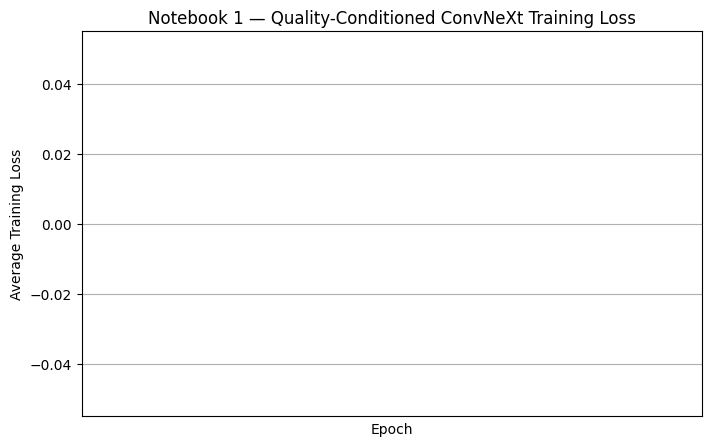

In [39]:
# ============================================================
# CELL 30 — PLOT TRAINING LOSS
# ============================================================

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(
    training_history["epoch"],
    training_history["train_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Notebook 1 — Quality-Conditioned ConvNeXt Training Loss")

plt.xticks(training_history["epoch"])

plt.grid(True)

plt.show()

In [40]:
# ============================================================
# CELL 31 — SAVE TRAINED MODEL CHECKPOINT
# ============================================================

MODEL_CHECKPOINT_PATH = os.path.join(
    ROOT,
    "quality_conditioned_convnext_checkpoint.pt"
)

torch.save(
    {
        "model_state_dict": training_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "training_history": training_history,
        "label_columns": LABEL_COLUMNS,
        "feature_dim": CONVNEXT_FEATURE_DIM,
        "quality_embedding_dim": QUALITY_EMBEDDING_DIM
    },
    MODEL_CHECKPOINT_PATH
)

print("Model checkpoint saved successfully.")
print("Path:")
print(MODEL_CHECKPOINT_PATH)

Model checkpoint saved successfully.
Path:
/content/drive/My Drive/Eye Disease/Dataset/quality_conditioned_convnext_checkpoint.pt


In [41]:
# ============================================================
# CELL 32 — DEFINE VALIDATION DATA PATH
# ============================================================

VAL_PATIENT_PATH = (
    "/content/drive/My Drive/Eye Disease/Dataset/"
    "val_patient_df.csv"
)

print("Validation patient-level path:")
print(VAL_PATIENT_PATH)

print("\nFile exists:")
print(os.path.exists(VAL_PATIENT_PATH))

Validation patient-level path:
/content/drive/My Drive/Eye Disease/Dataset/val_patient_df.csv

File exists:
True


In [42]:
# ============================================================
# CELL 33 — LOAD VALIDATION PATIENT DATA
# ============================================================

val_patient_df = pd.read_csv(
    VAL_PATIENT_PATH
)

print("=" * 70)
print("PATIENT-LEVEL VALIDATION DATA LOADED")
print("=" * 70)

print("\nShape:")
print(val_patient_df.shape)

print("\nColumns:")
print(val_patient_df.columns.tolist())

print("\nFirst 5 rows:")
display(val_patient_df.head())

print("\nData types:")
print(val_patient_df.dtypes)

PATIENT-LEVEL VALIDATION DATA LOADED

Shape:
(504, 11)

Columns:
['patient_id', 'right_filename', 'left_filename', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

First 5 rows:


,patient_id,right_filename,left_filename,N,D,G,C,A,H,M,O
0,7,7_right.jpg,7_left.jpg,0,1,0,0,0,0,0,1
1,13,13_right.jpg,13_left.jpg,0,0,0,0,0,0,1,0
2,18,18_right.jpg,18_left.jpg,0,0,0,0,0,0,1,0
3,24,24_right.jpg,24_left.jpg,0,0,0,1,0,0,0,0
4,27,27_right.jpg,27_left.jpg,0,1,0,0,0,0,0,1



Data types:
patient_id         int64
right_filename    object
left_filename     object
N                  int64
D                  int64
G                  int64
C                  int64
A                  int64
H                  int64
M                  int64
O                  int64
dtype: object


In [43]:
# ============================================================
# CELL 34 — VALIDATION PATIENT DATA CHECK
# ============================================================

print("=" * 70)
print("VALIDATION PATIENT DATA CHECK")
print("=" * 70)

print("\nTotal patient records:")
print(len(val_patient_df))

print("\nUnique patient IDs:")

# Try to identify the patient ID column from the known common names
possible_id_columns = [
    "patient_id",
    "ID",
    "id"
]

patient_id_column = None

for column in possible_id_columns:
    if column in val_patient_df.columns:
        patient_id_column = column
        break

if patient_id_column is not None:

    print(
        val_patient_df[patient_id_column].nunique()
    )

    print("\nPatient ID column:")
    print(patient_id_column)

else:

    print(
        "Patient ID column was not automatically identified."
    )

print("\nColumns containing 'left' or 'right':")

eye_related_columns = [
    column
    for column in val_patient_df.columns
    if (
        "left" in column.lower()
        or "right" in column.lower()
    )
]

print(eye_related_columns)

print("=" * 70)

VALIDATION PATIENT DATA CHECK

Total patient records:
504

Unique patient IDs:
504

Patient ID column:
patient_id

Columns containing 'left' or 'right':
['right_filename', 'left_filename']


In [44]:
# ============================================================
# CELL 35 — CONVERT VALIDATION PATIENT DATA TO EYE-LEVEL DATA
# ============================================================

LABEL_COLUMNS = [
    "N", "D", "G", "C",
    "A", "H", "M", "O"
]

val_eye_records = []

for _, row in val_patient_df.iterrows():

    # --------------------------------------------------------
    # RIGHT EYE
    # --------------------------------------------------------
    if pd.notna(row["right_filename"]):

        record = {
            "patient_id": row["patient_id"],
            "eye": "right",
            "filename": row["right_filename"]
        }

        for label in LABEL_COLUMNS:
            record[label] = row[label]

        val_eye_records.append(record)

    # --------------------------------------------------------
    # LEFT EYE
    # --------------------------------------------------------
    if pd.notna(row["left_filename"]):

        record = {
            "patient_id": row["patient_id"],
            "eye": "left",
            "filename": row["left_filename"]
        }

        for label in LABEL_COLUMNS:
            record[label] = row[label]

        val_eye_records.append(record)


val_eye_df = pd.DataFrame(val_eye_records)

print("=" * 70)
print("VALIDATION EYE-LEVEL DATA CREATED")
print("=" * 70)

print("\nOriginal patient records:", len(val_patient_df))
print("Eye-level records:", len(val_eye_df))
print("Unique patients:", val_eye_df["patient_id"].nunique())

print("\nColumns:")
print(val_eye_df.columns.tolist())

display(val_eye_df.head())

print("=" * 70)

VALIDATION EYE-LEVEL DATA CREATED

Original patient records: 504
Eye-level records: 942
Unique patients: 504

Columns:
['patient_id', 'eye', 'filename', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']


,patient_id,eye,filename,N,D,G,C,A,H,M,O
0,7,right,7_right.jpg,0,1,0,0,0,0,0,1
1,7,left,7_left.jpg,0,1,0,0,0,0,0,1
2,13,right,13_right.jpg,0,0,0,0,0,0,1,0
3,13,left,13_left.jpg,0,0,0,0,0,0,1,0
4,18,right,18_right.jpg,0,0,0,0,0,0,1,0


In [45]:
# ============================================================
# CELL 36 — ATTACH VALIDATION IMAGE PATHS
# ============================================================

val_eye_df["image_path"] = val_eye_df["filename"].apply(
    lambda filename: os.path.join(
        PREPROCESS_DIR,
        filename
    )
)

print("=" * 70)
print("VALIDATION IMAGE PATHS ATTACHED")
print("=" * 70)

print("\nTotal eye records:", len(val_eye_df))

print("\nFirst 5 image paths:")
print(
    val_eye_df[
        ["filename", "image_path"]
    ].head()
)

print("=" * 70)

VALIDATION IMAGE PATHS ATTACHED

Total eye records: 942

First 5 image paths:
       filename                                         image_path
0   7_right.jpg  /content/drive/My Drive/Eye Disease/Dataset/pr...
1    7_left.jpg  /content/drive/My Drive/Eye Disease/Dataset/pr...
2  13_right.jpg  /content/drive/My Drive/Eye Disease/Dataset/pr...
3   13_left.jpg  /content/drive/My Drive/Eye Disease/Dataset/pr...
4  18_right.jpg  /content/drive/My Drive/Eye Disease/Dataset/pr...


In [46]:
# ============================================================
# CELL 37 — VERIFY VALIDATION PREPROCESSED IMAGES
# ============================================================

missing_images = val_eye_df.loc[
    ~val_eye_df["image_path"].apply(os.path.exists),
    "filename"
].tolist()

print("=" * 70)
print("VALIDATION PREPROCESSED IMAGE CHECK")
print("=" * 70)

print("\nExpected validation eye images:", len(val_eye_df))
print("Missing images:", len(missing_images))

if len(missing_images) > 0:

    print("\nFirst 10 missing images:")
    print(missing_images[:10])

    raise FileNotFoundError(
        "Some validation images are missing from "
        "the preprocessed image directory."
    )

print(
    "\nSUCCESS: All validation eye images were found."
)

print("=" * 70)

VALIDATION PREPROCESSED IMAGE CHECK

Expected validation eye images: 942
Missing images: 0

SUCCESS: All validation eye images were found.


In [47]:
# ============================================================
# CELL 38 — DEFINE IMAGE QUALITY METRIC FUNCTIONS
# ============================================================

from skimage.measure import shannon_entropy
import cv2

def calculate_blur(image):
    """
    Variance of Laplacian.

    Higher value generally indicates a sharper image.
    """
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    return float(
        cv2.Laplacian(
            gray,
            cv2.CV_64F
        ).var()
    )


def calculate_brightness(image):
    """
    Mean grayscale intensity.
    """
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    return float(np.mean(gray))


def calculate_contrast(image):
    """
    Standard deviation of grayscale intensity.
    """
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    return float(np.std(gray))


def calculate_entropy(image):
    """
    Shannon entropy of grayscale image.
    """
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    return float(shannon_entropy(gray))


QUALITY_COLUMNS = [
    "blur",
    "brightness",
    "contrast",
    "entropy"
]

print("Quality metric functions defined successfully.")
print("Metrics:", QUALITY_COLUMNS)

Quality metric functions defined successfully.
Metrics: ['blur', 'brightness', 'contrast', 'entropy']


In [48]:
# ============================================================
# CELL 39 — COMPUTE RAW VALIDATION QUALITY METRICS
# ============================================================

from tqdm.auto import tqdm

validation_quality_metrics = []

for _, row in tqdm(
    val_eye_df.iterrows(),
    total=len(val_eye_df),
    desc="Computing validation quality metrics"
):

    image = cv2.imread(
        row["image_path"]
    )

    if image is None:
        raise ValueError(
            "OpenCV could not read image: "
            f"{row['image_path']}"
        )

    validation_quality_metrics.append(
        {
            "patient_id": row["patient_id"],
            "eye": row["eye"],
            "filename": row["filename"],
            "image_path": row["image_path"],

            "blur": calculate_blur(image),

            "brightness": calculate_brightness(
                image
            ),

            "contrast": calculate_contrast(
                image
            ),

            "entropy": calculate_entropy(
                image
            )
        }
    )


val_quality_raw_df = pd.DataFrame(
    validation_quality_metrics
)

print("=" * 70)
print("RAW VALIDATION QUALITY METRICS CALCULATED")
print("=" * 70)

print("\nValidation eye records:")
print(len(val_quality_raw_df))

print("\nColumns:")
print(val_quality_raw_df.columns.tolist())

display(val_quality_raw_df.head())

print("=" * 70)

Computing validation quality metrics:   0%|          | 0/942 [00:00<?, ?it/s]

RAW VALIDATION QUALITY METRICS CALCULATED

Validation eye records:
942

Columns:
['patient_id', 'eye', 'filename', 'image_path', 'blur', 'brightness', 'contrast', 'entropy']


,patient_id,eye,filename,image_path,blur,brightness,contrast,entropy
0,7,right,7_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,298.667946,108.283169,67.023312,6.306468
1,7,left,7_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,319.941864,116.007671,68.231345,6.182260
2,13,right,13_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,84.045688,50.269939,30.275105,5.489818
3,13,left,13_left.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,87.558103,45.625027,29.090596,5.601068
4,18,right,18_right.jpg,/content/drive/My Drive/Eye Disease/Dataset/pr...,161.228588,104.818821,46.572018,6.311549


In [49]:
# ============================================================
# CELL 40 — VERIFY RAW VALIDATION QUALITY METRICS
# ============================================================

print("=" * 70)
print("RAW VALIDATION QUALITY METRICS CHECK")
print("=" * 70)

print("\nTotal records:", len(val_quality_raw_df))

print(
    "Unique filenames:",
    val_quality_raw_df["filename"].nunique()
)

print("\nMissing values per metric:")
print(
    val_quality_raw_df[
        QUALITY_COLUMNS
    ].isna().sum()
)

all_finite = np.isfinite(
    val_quality_raw_df[
        QUALITY_COLUMNS
    ].to_numpy(dtype=float)
).all()

print("\nAll metric values finite:", all_finite)

assert (
    val_quality_raw_df["filename"].nunique()
    == len(val_quality_raw_df)
)

assert not val_quality_raw_df[
    QUALITY_COLUMNS
].isna().any().any()

assert all_finite

print(
    "\nSUCCESS: Raw validation quality metrics are valid."
)

print("=" * 70)

RAW VALIDATION QUALITY METRICS CHECK

Total records: 942
Unique filenames: 942

Missing values per metric:
blur          0
brightness    0
contrast      0
entropy       0
dtype: int64

All metric values finite: True

SUCCESS: Raw validation quality metrics are valid.


In [50]:
# ============================================================
# CELL 41 — SAVE RAW VALIDATION QUALITY METRICS
# ============================================================

VAL_QUALITY_METRICS_PATH = os.path.join(
    ROOT,
    "val_quality_metrics.csv"
)

val_quality_raw_df.to_csv(
    VAL_QUALITY_METRICS_PATH,
    index=False
)

print("=" * 70)
print("RAW VALIDATION QUALITY METRICS SAVED")
print("=" * 70)

print(VAL_QUALITY_METRICS_PATH)

print("\nRecords saved:", len(val_quality_raw_df))

print("=" * 70)

RAW VALIDATION QUALITY METRICS SAVED
/content/drive/My Drive/Eye Disease/Dataset/val_quality_metrics.csv

Records saved: 942


In [51]:
# ============================================================
# CELL 42 — LOAD TRAINING RAW QUALITY METRICS
# ============================================================

TRAIN_QUALITY_METRICS_PATH = os.path.join(
    ROOT,
    "train_quality_metrics.csv"
)

train_quality_raw_df = pd.read_csv(
    TRAIN_QUALITY_METRICS_PATH
)

print("=" * 70)
print("TRAINING RAW QUALITY METRICS LOADED")
print("=" * 70)

print("\nShape:", train_quality_raw_df.shape)

print("\nColumns:")
print(train_quality_raw_df.columns.tolist())

print("\nTraining eye records:", len(train_quality_raw_df))

print("\nRequired metric columns present:")

for column in QUALITY_COLUMNS:
    print(
        f"{column}:",
        column in train_quality_raw_df.columns
    )

print("=" * 70)

TRAINING RAW QUALITY METRICS LOADED

Shape: (4491, 5)

Columns:
['filename', 'blur', 'brightness', 'contrast', 'entropy']

Training eye records: 4491

Required metric columns present:
blur: True
brightness: True
contrast: True
entropy: True


In [52]:
# ============================================================
# CELL 43 — VERIFY TRAINING QUALITY METRICS
# ============================================================

print("=" * 70)
print("TRAINING QUALITY METRICS CHECK")
print("=" * 70)

print("\nTotal training records:")
print(len(train_quality_raw_df))

print("\nExpected Stage-1 training records: 4491")

print("\nMissing values:")
print(
    train_quality_raw_df[
        QUALITY_COLUMNS
    ].isna().sum()
)

training_metrics_finite = np.isfinite(
    train_quality_raw_df[
        QUALITY_COLUMNS
    ].to_numpy(dtype=float)
).all()

print(
    "\nAll training metric values finite:",
    training_metrics_finite
)

assert len(train_quality_raw_df) == 4491

assert not train_quality_raw_df[
    QUALITY_COLUMNS
].isna().any().any()

assert training_metrics_finite

print(
    "\nSUCCESS: Training metrics are valid "
    "and ready to define the normalization scale."
)

print("=" * 70)

TRAINING QUALITY METRICS CHECK

Total training records:
4491

Expected Stage-1 training records: 4491

Missing values:
blur          0
brightness    0
contrast      0
entropy       0
dtype: int64

All training metric values finite: True

SUCCESS: Training metrics are valid and ready to define the normalization scale.


In [53]:
# ============================================================
# CELL 44 — FIT NORMALIZATION SCALER ON TRAINING DATA ONLY
# ============================================================

from sklearn.preprocessing import MinMaxScaler

quality_scaler = MinMaxScaler()

quality_scaler.fit(
    train_quality_raw_df[
        QUALITY_COLUMNS
    ]
)

print("=" * 70)
print("TRAINING-FITTED QUALITY SCALER CREATED")
print("=" * 70)

print("\nMetric order:")
print(QUALITY_COLUMNS)

print("\nTraining minimum values:")
print(
    pd.Series(
        quality_scaler.data_min_,
        index=QUALITY_COLUMNS
    )
)

print("\nTraining maximum values:")
print(
    pd.Series(
        quality_scaler.data_max_,
        index=QUALITY_COLUMNS
    )
)

print("=" * 70)

TRAINING-FITTED QUALITY SCALER CREATED

Metric order:
['blur', 'brightness', 'contrast', 'entropy']

Training minimum values:
blur          2.814586
brightness    5.228615
contrast      6.301911
entropy       3.815665
dtype: float64

Training maximum values:
blur          1744.217682
brightness     188.285507
contrast       102.495922
entropy          7.422370
dtype: float64


In [54]:
# ============================================================
# CELL 45 — TRANSFORM VALIDATION METRICS USING TRAINING SCALER
# ============================================================

val_quality_normalized_df = val_quality_raw_df.copy()

val_quality_normalized_df[
    QUALITY_COLUMNS
] = quality_scaler.transform(
    val_quality_raw_df[
        QUALITY_COLUMNS
    ]
)

print("=" * 70)
print("VALIDATION METRICS NORMALIZED")
print("=" * 70)

print(
    "\nNormalization used the training-fitted scaler only."
)

print("\nValidation normalized metric statistics:")
display(
    val_quality_normalized_df[
        QUALITY_COLUMNS
    ].describe()
)

print("=" * 70)

VALIDATION METRICS NORMALIZED

Normalization used the training-fitted scaler only.

Validation normalized metric statistics:


,blur,brightness,contrast,entropy
count,942.000000,942.000000,942.000000,942.000000
mean,0.159612,0.405342,0.432701,0.578645
std,0.121884,0.133592,0.136825,0.116719
min,0.008220,0.075242,0.067695,0.029698
25%,0.081371,0.310999,0.332957,0.508795
50%,0.132707,0.396912,0.429532,0.593236
75%,0.197476,0.499821,0.519552,0.654061
max,1.488539,0.858503,0.892209,0.926770


In [55]:
# ============================================================
# CELL 46 — CREATE TRAINING REFERENCE DISTRIBUTION
# ============================================================

# Normalize the training metrics using the SAME scaler
# that was fitted only on training data.
train_quality_normalized_df = train_quality_raw_df.copy()

train_quality_normalized_df[
    QUALITY_COLUMNS
] = quality_scaler.transform(
    train_quality_raw_df[
        QUALITY_COLUMNS
    ]
)

# Calculate training reference statistics
reference_mean = train_quality_normalized_df[
    QUALITY_COLUMNS
].mean()

reference_std = train_quality_normalized_df[
    QUALITY_COLUMNS
].std()

reference_distribution_df = pd.DataFrame(
    {
        "reference_mean": reference_mean,
        "reference_std": reference_std
    }
)

print("=" * 70)
print("TRAINING QUALITY REFERENCE DISTRIBUTION CREATED")
print("=" * 70)

print("\nReference statistics:")
display(reference_distribution_df)

# Standard deviations must be positive
assert (reference_std > 0).all()

print(
    "\nSUCCESS: Training reference distributions are valid."
)

print("=" * 70)

TRAINING QUALITY REFERENCE DISTRIBUTION CREATED

Reference statistics:


,reference_mean,reference_std
blur,0.158822,0.114601
brightness,0.408796,0.139417
contrast,0.436796,0.143015
entropy,0.579668,0.121210



SUCCESS: Training reference distributions are valid.


In [56]:
# ============================================================
# CELL 47 — CALCULATE TRAINING REFERENCE-DEVIATION SCORES
# ============================================================

train_deviation_df = train_quality_normalized_df.copy()

DEVIATION_COLUMNS = []

for metric in QUALITY_COLUMNS:

    deviation_column = f"{metric}_deviation"

    train_deviation_df[deviation_column] = (
        (
            train_deviation_df[metric]
            - reference_mean[metric]
        ).abs()
        / reference_std[metric]
    )

    DEVIATION_COLUMNS.append(
        deviation_column
    )

# Average standardized deviations across all four metrics
train_deviation_df[
    "reference_deviation_score"
] = train_deviation_df[
    DEVIATION_COLUMNS
].mean(axis=1)

print("=" * 70)
print("TRAINING REFERENCE-DEVIATION SCORES CALCULATED")
print("=" * 70)

print("\nDeviation columns:")
print(DEVIATION_COLUMNS)

print("\nTraining deviation statistics:")
display(
    train_deviation_df[
        "reference_deviation_score"
    ].describe()
)

assert np.isfinite(
    train_deviation_df[
        "reference_deviation_score"
    ]
).all()

print(
    "\nSUCCESS: Training deviation distribution created."
)

print("=" * 70)

TRAINING REFERENCE-DEVIATION SCORES CALCULATED

Deviation columns:
['blur_deviation', 'brightness_deviation', 'contrast_deviation', 'entropy_deviation']

Training deviation statistics:


,reference_deviation_score
count,4491.000000
mean,0.781184
std,0.460698
min,0.037305
25%,0.454850
50%,0.679816
75%,1.005797
max,3.880011



SUCCESS: Training deviation distribution created.


In [57]:
# ============================================================
# CELL 48 — EXTRACT TRAINING DEVIATION RANGE
# ============================================================

training_deviation_min = train_deviation_df[
    "reference_deviation_score"
].min()

training_deviation_max = train_deviation_df[
    "reference_deviation_score"
].max()

print("=" * 70)
print("TRAINING DEVIATION REFERENCE RANGE")
print("=" * 70)

print(
    "\nMinimum deviation:",
    training_deviation_min
)

print(
    "Maximum deviation:",
    training_deviation_max
)

assert (
    training_deviation_max
    > training_deviation_min
)

print(
    "\nSUCCESS: Training-derived deviation range is valid."
)

print("=" * 70)

TRAINING DEVIATION REFERENCE RANGE

Minimum deviation: 0.03730495424521758
Maximum deviation: 3.880010711455295

SUCCESS: Training-derived deviation range is valid.


In [58]:
# ============================================================
# CELL 49 — CALCULATE VALIDATION METRIC DEVIATIONS
# ============================================================

val_deviation_df = val_quality_normalized_df.copy()

for metric in QUALITY_COLUMNS:

    deviation_column = f"{metric}_deviation"

    val_deviation_df[deviation_column] = (
        (
            val_deviation_df[metric]
            - reference_mean[metric]
        ).abs()
        / reference_std[metric]
    )

print("=" * 70)
print("VALIDATION METRIC DEVIATIONS CALCULATED")
print("=" * 70)

print("\nDeviation columns:")
print(DEVIATION_COLUMNS)

print("\nDeviation statistics:")
display(
    val_deviation_df[
        DEVIATION_COLUMNS
    ].describe()
)

assert not val_deviation_df[
    DEVIATION_COLUMNS
].isna().any().any()

assert np.isfinite(
    val_deviation_df[
        DEVIATION_COLUMNS
    ].to_numpy()
).all()

print(
    "\nSUCCESS: All validation deviations are valid."
)

print("=" * 70)

VALIDATION METRIC DEVIATIONS CALCULATED

Deviation columns:
['blur_deviation', 'brightness_deviation', 'contrast_deviation', 'entropy_deviation']

Deviation statistics:


,blur_deviation,brightness_deviation,contrast_deviation,entropy_deviation
count,942.000000,942.000000,942.000000,942.000000
mean,0.722496,0.773269,0.761556,0.748723
std,0.780148,0.565883,0.579264,0.605116
min,0.000541,0.000937,0.002453,0.001753
25%,0.269719,0.310741,0.287959,0.291278
50%,0.593459,0.668707,0.663241,0.599296
75%,0.944462,1.089736,1.134802,1.079400
max,11.603033,3.225639,3.184365,4.537352



SUCCESS: All validation deviations are valid.


In [59]:
# ============================================================
# CELL 50 — CALCULATE VALIDATION REFERENCE-DEVIATION SCORE
# ============================================================

val_deviation_df[
    "reference_deviation_score"
] = val_deviation_df[
    DEVIATION_COLUMNS
].mean(axis=1)

print("=" * 70)
print("VALIDATION REFERENCE-DEVIATION SCORES CALCULATED")
print("=" * 70)

print("\nDeviation-score statistics:")
display(
    val_deviation_df[
        "reference_deviation_score"
    ].describe()
)

print(
    "\nTraining deviation range:"
)

print(
    "Min:",
    training_deviation_min
)

print(
    "Max:",
    training_deviation_max
)

print(
    "\nValidation images above training maximum:",
    (
        val_deviation_df[
            "reference_deviation_score"
        ] > training_deviation_max
    ).sum()
)

print(
    "\nSUCCESS: Validation reference-deviation scores calculated."
)

print("=" * 70)

VALIDATION REFERENCE-DEVIATION SCORES CALCULATED

Deviation-score statistics:


,reference_deviation_score
count,942.000000
mean,0.751511
std,0.446233
min,0.069130
25%,0.418099
50%,0.662282
75%,0.965990
max,3.201522



Training deviation range:
Min: 0.03730495424521758
Max: 3.880010711455295

Validation images above training maximum: 0

SUCCESS: Validation reference-deviation scores calculated.


In [60]:
# ============================================================
# CELL 51 — CONVERT VALIDATION DEVIATION TO QUALITY SCORE
# ============================================================

# Normalize using the FIXED training deviation range
val_deviation_df[
    "normalized_deviation_raw"
] = (
    val_deviation_df[
        "reference_deviation_score"
    ]
    - training_deviation_min
) / (
    training_deviation_max
    - training_deviation_min
)

# Keep the final normalized deviation within [0, 1]
val_deviation_df[
    "normalized_deviation"
] = val_deviation_df[
    "normalized_deviation_raw"
].clip(
    lower=0.0,
    upper=1.0
)

# Invert deviation:
# higher deviation = lower quality
val_deviation_df[
    "quality_score"
] = (
    1.0
    - val_deviation_df[
        "normalized_deviation"
    ]
)

print("=" * 70)
print("FINAL VALIDATION QUALITY SCORES CALCULATED")
print("=" * 70)

print("\nRaw normalized deviation statistics:")
display(
    val_deviation_df[
        "normalized_deviation_raw"
    ].describe()
)

print("\nFinal quality-score statistics:")
display(
    val_deviation_df[
        "quality_score"
    ].describe()
)

print("\nQuality scores below 0:")
print(
    (val_deviation_df["quality_score"] < 0).sum()
)

print("\nQuality scores above 1:")
print(
    (val_deviation_df["quality_score"] > 1).sum()
)

assert (
    val_deviation_df[
        "quality_score"
    ].between(0, 1).all()
)

print(
    "\nSUCCESS: All final validation quality scores are in [0, 1]."
)

print("=" * 70)

FINAL VALIDATION QUALITY SCORES CALCULATED

Raw normalized deviation statistics:


,normalized_deviation_raw
count,942.000000
mean,0.185860
std,0.116125
min,0.008282
25%,0.099095
50%,0.162640
75%,0.241675
max,0.823435



Final quality-score statistics:


,quality_score
count,942.000000
mean,0.814140
std,0.116125
min,0.176565
25%,0.758325
50%,0.837360
75%,0.900905
max,0.991718



Quality scores below 0:
0

Quality scores above 1:
0

SUCCESS: All final validation quality scores are in [0, 1].


In [61]:
# ============================================================
# CELL 52 — FINAL VALIDATION QUALITY-SCORE CHECK
# ============================================================

print("=" * 70)
print("FINAL VALIDATION QUALITY-SCORE INTEGRITY CHECK")
print("=" * 70)

print(
    "\nTotal validation records:",
    len(val_deviation_df)
)

print(
    "Unique filenames:",
    val_deviation_df[
        "filename"
    ].nunique()
)

print(
    "\nMissing quality scores:",
    val_deviation_df[
        "quality_score"
    ].isna().sum()
)

print(
    "Minimum quality score:",
    val_deviation_df[
        "quality_score"
    ].min()
)

print(
    "Maximum quality score:",
    val_deviation_df[
        "quality_score"
    ].max()
)

assert len(val_deviation_df) == 942

assert (
    val_deviation_df[
        "filename"
    ].nunique()
    == 942
)

assert not val_deviation_df[
    "quality_score"
].isna().any()

assert val_deviation_df[
    "quality_score"
].between(0, 1).all()

print(
    "\nSUCCESS: Validation quality scores are complete "
    "and ready to save."
)

print("=" * 70)

FINAL VALIDATION QUALITY-SCORE INTEGRITY CHECK

Total validation records: 942
Unique filenames: 942

Missing quality scores: 0
Minimum quality score: 0.17656546108792837
Maximum quality score: 0.9917180314604431

SUCCESS: Validation quality scores are complete and ready to save.


In [62]:
# ============================================================
# CELL 53 — CREATE FINAL VALIDATION QUALITY-SCORE DATAFRAME
# ============================================================

val_quality_scores_df = val_deviation_df[
    [
        "filename",
        "patient_id",
        "eye",
        "reference_deviation_score",
        "normalized_deviation",
        "quality_score"
    ]
].copy()

print("=" * 70)
print("FINAL VALIDATION QUALITY-SCORE DATAFRAME CREATED")
print("=" * 70)

print("\nShape:", val_quality_scores_df.shape)

print("\nColumns:")
print(val_quality_scores_df.columns.tolist())

print("\nFirst 5 rows:")
display(val_quality_scores_df.head())

print("=" * 70)

FINAL VALIDATION QUALITY-SCORE DATAFRAME CREATED

Shape: (942, 6)

Columns:
['filename', 'patient_id', 'eye', 'reference_deviation_score', 'normalized_deviation', 'quality_score']

First 5 rows:


,filename,patient_id,eye,reference_deviation_score,normalized_deviation,quality_score
0,7_right.jpg,7,right,0.869314,0.216516,0.783484
1,7_left.jpg,7,left,0.922555,0.230371,0.769629
2,13_right.jpg,13,right,1.102644,0.277237,0.722763
3,13_left.jpg,13,left,1.101650,0.276978,0.723022
4,18_right.jpg,18,right,0.654001,0.160485,0.839515


In [63]:
# ============================================================
# CELL 54 — VERIFY VALIDATION QUALITY-SCORE ALIGNMENT
# ============================================================

print("=" * 70)
print("VALIDATION QUALITY-SCORE ALIGNMENT CHECK")
print("=" * 70)

print("\nTotal quality-score records:")
print(len(val_quality_scores_df))

print("\nUnique filenames:")
print(val_quality_scores_df["filename"].nunique())

duplicate_filenames = val_quality_scores_df[
    "filename"
].duplicated().sum()

print("\nDuplicate filenames:")
print(duplicate_filenames)

missing_scores = val_quality_scores_df[
    "quality_score"
].isna().sum()

print("\nMissing quality scores:")
print(missing_scores)

assert len(val_quality_scores_df) == 942
assert val_quality_scores_df["filename"].nunique() == 942
assert duplicate_filenames == 0
assert missing_scores == 0

print(
    "\nSUCCESS: Every validation eye has exactly one "
    "valid quality score."
)

print("=" * 70)

VALIDATION QUALITY-SCORE ALIGNMENT CHECK

Total quality-score records:
942

Unique filenames:
942

Duplicate filenames:
0

Missing quality scores:
0

SUCCESS: Every validation eye has exactly one valid quality score.


In [64]:
# ============================================================
# CELL 55 — SAVE FINAL VALIDATION QUALITY SCORES
# ============================================================

VAL_QUALITY_SCORE_PATH = os.path.join(
    ROOT,
    "val_quality_scores.csv"
)

val_quality_scores_df.to_csv(
    VAL_QUALITY_SCORE_PATH,
    index=False
)

print("=" * 70)
print("FINAL VALIDATION QUALITY SCORES SAVED")
print("=" * 70)

print("\nPath:")
print(VAL_QUALITY_SCORE_PATH)

print("\nRecords saved:")
print(len(val_quality_scores_df))

print("=" * 70)

FINAL VALIDATION QUALITY SCORES SAVED

Path:
/content/drive/My Drive/Eye Disease/Dataset/val_quality_scores.csv

Records saved:
942


In [65]:
# ============================================================
# CELL 56 — CREATE FINAL VALIDATION MODEL DATASET
# ============================================================

val_model_df = val_eye_df.merge(
    val_quality_scores_df,
    on=[
        "patient_id",
        "eye",
        "filename"
    ],
    how="left",
    validate="one_to_one"
)

# Attach image paths
val_model_df["image_path"] = val_model_df[
    "filename"
].apply(
    lambda filename: os.path.join(
        PREPROCESS_DIR,
        filename
    )
)

print("=" * 70)
print("FINAL VALIDATION MODEL DATASET CREATED")
print("=" * 70)

print("\nShape:", val_model_df.shape)

print("\nColumns:")
print(val_model_df.columns.tolist())

print("\nMissing quality scores:")
print(val_model_df["quality_score"].isna().sum())

print("\nFirst 5 records:")
display(val_model_df.head())

print("=" * 70)

FINAL VALIDATION MODEL DATASET CREATED

Shape: (942, 15)

Columns:
['patient_id', 'eye', 'filename', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'image_path', 'reference_deviation_score', 'normalized_deviation', 'quality_score']

Missing quality scores:
0

First 5 records:


,patient_id,eye,filename,N,D,G,C,A,H,M,O,image_path,reference_deviation_score,normalized_deviation,quality_score
0,7,right,7_right.jpg,0,1,0,0,0,0,0,1,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.869314,0.216516,0.783484
1,7,left,7_left.jpg,0,1,0,0,0,0,0,1,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.922555,0.230371,0.769629
2,13,right,13_right.jpg,0,0,0,0,0,0,1,0,/content/drive/My Drive/Eye Disease/Dataset/pr...,1.102644,0.277237,0.722763
3,13,left,13_left.jpg,0,0,0,0,0,0,1,0,/content/drive/My Drive/Eye Disease/Dataset/pr...,1.101650,0.276978,0.723022
4,18,right,18_right.jpg,0,0,0,0,0,0,1,0,/content/drive/My Drive/Eye Disease/Dataset/pr...,0.654001,0.160485,0.839515


In [66]:
# ============================================================
# CELL 57 — FINAL VALIDATION DATASET INTEGRITY CHECK
# ============================================================

print("=" * 70)
print("FINAL VALIDATION DATASET INTEGRITY CHECK")
print("=" * 70)

print("\nTotal eye records:", len(val_model_df))

print(
    "Unique patients:",
    val_model_df["patient_id"].nunique()
)

print(
    "Unique filenames:",
    val_model_df["filename"].nunique()
)

print(
    "\nMissing image paths:",
    val_model_df["image_path"].isna().sum()
)

print(
    "Missing quality scores:",
    val_model_df["quality_score"].isna().sum()
)

print(
    "\nQuality scores in [0, 1]:",
    val_model_df["quality_score"].between(
        0, 1
    ).all()
)

print("\nDisease label columns:")
print(LABEL_COLUMNS)

assert len(val_model_df) == 942
assert val_model_df["patient_id"].nunique() == 504
assert val_model_df["filename"].nunique() == 942
assert val_model_df["image_path"].isna().sum() == 0
assert val_model_df["quality_score"].isna().sum() == 0
assert val_model_df["quality_score"].between(0, 1).all()

for label in LABEL_COLUMNS:
    assert label in val_model_df.columns

print(
    "\nSUCCESS: Validation data is fully ready for "
    "PyTorch model evaluation."
)

print("=" * 70)

FINAL VALIDATION DATASET INTEGRITY CHECK

Total eye records: 942
Unique patients: 504
Unique filenames: 942

Missing image paths: 0
Missing quality scores: 0

Quality scores in [0, 1]: True

Disease label columns:
['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

SUCCESS: Validation data is fully ready for PyTorch model evaluation.


In [67]:
# ============================================================
# CELL 58 — CREATE VALIDATION PYTORCH DATASET
# ============================================================

class ValidationEyeDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Read image
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        # Apply the same image transform
        if self.transform is not None:
            image = self.transform(image)

        # Quality score
        quality_score = torch.tensor(
            row["quality_score"],
            dtype=torch.float32
        )

        # Multi-label disease target
        labels = torch.tensor(
            row[LABEL_COLUMNS].values.astype(
                np.float32
            ),
            dtype=torch.float32
        )

        return (
            image,
            quality_score,
            labels
        )


val_dataset = ValidationEyeDataset(
    dataframe=val_model_df,
    transform=image_transform
)

print("=" * 70)
print("VALIDATION PYTORCH DATASET CREATED")
print("=" * 70)

print("\nTotal validation samples:")
print(len(val_dataset))

print(
    "\nSUCCESS: Validation dataset is ready."
)

print("=" * 70)

VALIDATION PYTORCH DATASET CREATED

Total validation samples:
942

SUCCESS: Validation dataset is ready.


In [68]:
# ============================================================
# CELL 59 — CREATE VALIDATION DATALOADER + SANITY CHECK
# ============================================================

VAL_BATCH_SIZE = 16

val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 70)
print("VALIDATION DATALOADER CREATED")
print("=" * 70)

print("\nBatch size:", VAL_BATCH_SIZE)

print(
    "Total validation batches:",
    len(val_loader)
)

# Get one batch for verification
val_images, val_quality, val_labels = next(
    iter(val_loader)
)

print("\nVALIDATION BATCH CHECK")

print(
    "\nImage batch shape:",
    val_images.shape
)

print(
    "Quality-score batch shape:",
    val_quality.shape
)

print(
    "Label batch shape:",
    val_labels.shape
)

assert val_images.shape[1:] == (3, 224, 224)
assert val_quality.ndim == 1
assert val_labels.shape[1] == 8

print(
    "\nSUCCESS: Validation DataLoader output "
    "matches model input requirements."
)

print("=" * 70)

VALIDATION DATALOADER CREATED

Batch size: 16
Total validation batches: 59

VALIDATION BATCH CHECK

Image batch shape: torch.Size([16, 3, 224, 224])
Quality-score batch shape: torch.Size([16])
Label batch shape: torch.Size([16, 8])

SUCCESS: Validation DataLoader output matches model input requirements.


In [69]:
# ============================================================
# CELL 60 — CHECK DEVICE AND LOAD TRAINED CHECKPOINT
# ============================================================

# Select available device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("VALIDATION DEVICE CHECK")
print("=" * 70)

print("\nDevice:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
else:
    print(
        "\nWARNING: GPU is not available. "
        "Validation will run on CPU and may be slower."
    )

# Load saved checkpoint
CHECKPOINT_PATH = os.path.join(
    ROOT,
    "quality_conditioned_convnext_checkpoint.pt"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

print("\nCheckpoint loaded successfully.")

print("\nCheckpoint type:")
print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    print(checkpoint.keys())

print("=" * 70)

VALIDATION DEVICE CHECK

Device: cuda
GPU: Tesla T4

Checkpoint loaded successfully.

Checkpoint type:
<class 'dict'>

Checkpoint keys:
dict_keys(['model_state_dict', 'optimizer_state_dict', 'training_history', 'label_columns', 'feature_dim', 'quality_embedding_dim'])


In [70]:
# ============================================================
# CELL 61 — RESTORE ACTUAL TRAINED MODEL FROM CHECKPOINT
# ============================================================

# Load the saved trained weights
training_model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Switch to evaluation mode
training_model.eval()

# We will use this name during validation
validation_model = training_model

print("=" * 70)
print("TRAINED MODEL RESTORED SUCCESSFULLY")
print("=" * 70)

print("\nModel class:")
print(type(validation_model).__name__)

print("\nEvaluation mode:")
print(not validation_model.training)

print("\nModel device:")
print(next(validation_model.parameters()).device)

print("\nCheckpoint feature dimension:")
print(checkpoint["feature_dim"])

print("\nCheckpoint quality embedding dimension:")
print(checkpoint["quality_embedding_dim"])

print("\nCheckpoint labels:")
print(checkpoint["label_columns"])

print("\nSUCCESS: Original trained model is restored and ready for validation.")

print("=" * 70)

TRAINED MODEL RESTORED SUCCESSFULLY

Model class:
QualityConditionedDiseaseModel

Evaluation mode:
True

Model device:
cuda:0

Checkpoint feature dimension:
768

Checkpoint quality embedding dimension:
64

Checkpoint labels:
['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

SUCCESS: Original trained model is restored and ready for validation.


In [71]:
# ============================================================
# CELL 62 — DEFINE VALIDATION LOSS
# ============================================================

validation_criterion = nn.BCEWithLogitsLoss()

print("=" * 70)
print("VALIDATION LOSS CONFIGURED")
print("=" * 70)

print("\nLoss function: BCEWithLogitsLoss")

print("\nValidation uses the natural, unbalanced patient split.")

print("\nNo sample weights, optimizer updates, or backpropagation "
      "will be used.")

print("=" * 70)

VALIDATION LOSS CONFIGURED

Loss function: BCEWithLogitsLoss

Validation uses the natural, unbalanced patient split.

No sample weights, optimizer updates, or backpropagation will be used.


In [72]:
# ============================================================
# CELL 63 — RUN FULL VALIDATION
# ============================================================

validation_model.eval()

total_validation_loss = 0.0
total_validation_samples = 0

all_logits = []
all_probabilities = []
all_true_labels = []

print("=" * 70)
print("RUNNING FULL VALIDATION")
print("=" * 70)

with torch.no_grad():

    for images, quality_scores, labels in tqdm(
        val_loader,
        desc="Validating"
    ):

        # Move data to GPU
        images = images.to(device)
        quality_scores = quality_scores.to(device)
        labels = labels.to(device)

        # Forward pass
        logits, features = validation_model(
            images,
            quality_scores
        )

        # Calculate validation loss
        loss = validation_criterion(
            logits,
            labels
        )

        batch_size = images.size(0)

        total_validation_loss += (
            loss.item() * batch_size
        )

        total_validation_samples += batch_size

        # Convert independent multi-label logits
        # into probabilities
        probabilities = torch.sigmoid(logits)

        # Store outputs on CPU
        all_logits.append(logits.cpu())
        all_probabilities.append(probabilities.cpu())
        all_true_labels.append(labels.cpu())


# Combine results from all batches
all_logits = torch.cat(
    all_logits,
    dim=0
)

all_probabilities = torch.cat(
    all_probabilities,
    dim=0
)

all_true_labels = torch.cat(
    all_true_labels,
    dim=0
)


# Calculate average validation loss
average_validation_loss = (
    total_validation_loss
    / total_validation_samples
)


print("\n" + "=" * 70)
print("VALIDATION COMPLETED")
print("=" * 70)

print("\nTotal samples evaluated:")
print(total_validation_samples)

print("\nAverage validation loss:")
print(average_validation_loss)

print("\nLogits shape:")
print(all_logits.shape)

print("\nProbabilities shape:")
print(all_probabilities.shape)

print("\nTrue labels shape:")
print(all_true_labels.shape)


assert total_validation_samples == 942

assert all_logits.shape == (942, NUM_CLASSES)

assert all_probabilities.shape == (
    942,
    NUM_CLASSES
)

assert all_true_labels.shape == (
    942,
    NUM_CLASSES
)

print(
    "\nSUCCESS: All validation samples were evaluated successfully."
)

print("=" * 70)

RUNNING FULL VALIDATION


Validating:   0%|          | 0/59 [00:00<?, ?it/s]


VALIDATION COMPLETED

Total samples evaluated:
942

Average validation loss:
0.6368461081683003

Logits shape:
torch.Size([942, 8])

Probabilities shape:
torch.Size([942, 8])

True labels shape:
torch.Size([942, 8])

SUCCESS: All validation samples were evaluated successfully.


In [73]:
# ============================================================
# CELL 64 — VALIDATION PREDICTION INTEGRITY CHECK
# ============================================================

probabilities_np = all_probabilities.numpy()

true_labels_np = (
    all_true_labels.numpy()
    .astype(int)
)

print("=" * 70)
print("VALIDATION PREDICTION INTEGRITY CHECK")
print("=" * 70)

print("\nProbability minimum:")
print(probabilities_np.min())

print("\nProbability maximum:")
print(probabilities_np.max())

print("\nAll probabilities finite:")
print(np.isfinite(probabilities_np).all())

print("\nAll probabilities in [0, 1]:")
print(
    (
        (probabilities_np >= 0).all()
        and (probabilities_np <= 1).all()
    )
)

print("\nPrediction array shape:")
print(probabilities_np.shape)

print("\nTrue-label array shape:")
print(true_labels_np.shape)

print("\nTotal positive validation labels:")
print(true_labels_np.sum())


assert np.isfinite(probabilities_np).all()

assert (probabilities_np >= 0).all()

assert (probabilities_np <= 1).all()

assert probabilities_np.shape == (942, NUM_CLASSES)

assert true_labels_np.shape == (
    942,
    NUM_CLASSES
)

print(
    "\nSUCCESS: Validation predictions are valid "
    "and ready for metric calculation."
)

print("=" * 70)

VALIDATION PREDICTION INTEGRITY CHECK

Probability minimum:
0.4000055

Probability maximum:
0.5457184

All probabilities finite:
True

All probabilities in [0, 1]:
True

Prediction array shape:
(942, 8)

True-label array shape:
(942, 8)

Total positive validation labels:
1096

SUCCESS: Validation predictions are valid and ready for metric calculation.


In [74]:
# ============================================================
# CELL 65 — INITIAL MULTI-LABEL METRICS AT THRESHOLD 0.5
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

THRESHOLD = 0.5

predictions_np = (
    probabilities_np >= THRESHOLD
).astype(int)


micro_precision = precision_score(
    true_labels_np,
    predictions_np,
    average="micro",
    zero_division=0
)

micro_recall = recall_score(
    true_labels_np,
    predictions_np,
    average="micro",
    zero_division=0
)

micro_f1 = f1_score(
    true_labels_np,
    predictions_np,
    average="micro",
    zero_division=0
)


macro_precision = precision_score(
    true_labels_np,
    predictions_np,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    true_labels_np,
    predictions_np,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    true_labels_np,
    predictions_np,
    average="macro",
    zero_division=0
)


print("=" * 70)
print("INITIAL VALIDATION MULTI-LABEL METRICS")
print("=" * 70)

print(f"\nThreshold: {THRESHOLD}")

print("\nMICRO METRICS")
print(
    f"Precision: {micro_precision:.4f}"
)
print(
    f"Recall:    {micro_recall:.4f}"
)
print(
    f"F1 Score:  {micro_f1:.4f}"
)

print("\nMACRO METRICS")
print(
    f"Precision: {macro_precision:.4f}"
)
print(
    f"Recall:    {macro_recall:.4f}"
)
print(
    f"F1 Score:  {macro_f1:.4f}"
)

print("=" * 70)

INITIAL VALIDATION MULTI-LABEL METRICS

Threshold: 0.5

MICRO METRICS
Precision: 0.2195
Recall:    0.0246
F1 Score:  0.0443

MACRO METRICS
Precision: 0.2332
Recall:    0.0222
F1 Score:  0.0399


In [75]:
# ============================================================
# CELL 66 — PER-DISEASE VALIDATION METRICS
# ============================================================

per_label_precision = precision_score(
    true_labels_np,
    predictions_np,
    average=None,
    zero_division=0
)

per_label_recall = recall_score(
    true_labels_np,
    predictions_np,
    average=None,
    zero_division=0
)

per_label_f1 = f1_score(
    true_labels_np,
    predictions_np,
    average=None,
    zero_division=0
)

per_label_support = true_labels_np.sum(
    axis=0
)


per_disease_results_df = pd.DataFrame(
    {
        "Disease": LABEL_COLUMNS,
        "Support": per_label_support,
        "Precision": per_label_precision,
        "Recall": per_label_recall,
        "F1": per_label_f1
    }
)

print("=" * 70)
print("PER-DISEASE VALIDATION PERFORMANCE")
print("=" * 70)

display(
    per_disease_results_df
)

print("\nSUCCESS: Per-disease metrics calculated.")

print("=" * 70)

PER-DISEASE VALIDATION PERFORMANCE


,Disease,Support,Precision,Recall,F1
0,N,278,0.333333,0.010791,0.020906
1,D,315,0.115942,0.025397,0.041667
2,G,76,0.000000,0.000000,0.000000
3,C,44,0.750000,0.068182,0.125000
4,A,40,0.000000,0.000000,0.000000
5,H,38,0.333333,0.026316,0.048780
6,M,51,0.000000,0.000000,0.000000
7,O,254,0.333333,0.047244,0.082759



SUCCESS: Per-disease metrics calculated.


In [76]:
# ============================================================
# CELL 67 — TRUE VS PREDICTED DISEASE FREQUENCY
# ============================================================

actual_positive_counts = true_labels_np.sum(
    axis=0
)

predicted_positive_counts = predictions_np.sum(
    axis=0
)

frequency_comparison_df = pd.DataFrame(
    {
        "Disease": LABEL_COLUMNS,
        "Actual Positives": actual_positive_counts,
        "Predicted Positives": predicted_positive_counts,
        "Difference": (
            predicted_positive_counts
            - actual_positive_counts
        )
    }
)

print("=" * 70)
print("TRUE VS PREDICTED DISEASE FREQUENCY")
print("=" * 70)

display(
    frequency_comparison_df
)

print(
    "\nPositive predictions across all labels:",
    predicted_positive_counts.sum()
)

print(
    "Actual positive labels across all labels:",
    actual_positive_counts.sum()
)

print("=" * 70)

TRUE VS PREDICTED DISEASE FREQUENCY


,Disease,Actual Positives,Predicted Positives,Difference
0,N,278,9,-269
1,D,315,69,-246
2,G,76,2,-74
3,C,44,4,-40
4,A,40,0,-40
5,H,38,3,-35
6,M,51,0,-51
7,O,254,36,-218



Positive predictions across all labels: 123
Actual positive labels across all labels: 1096


In [77]:
# ============================================================
# CELL 68 — PREPARE STAGE-1 DATA FOR FEATURE EXTRACTION
# ============================================================

# Reuse the already prepared Stage-1 model dataset
prototype_df = model_df.copy()

print("=" * 70)
print("STAGE-1 DATA PREPARED FOR DISEASE PROTOTYPE EXTRACTION")
print("=" * 70)

print("\nTotal training eyes:")
print(len(prototype_df))

print("\nUnique patients:")
print(prototype_df["patient_id"].nunique())

print("\nFeature dimension to extract:")
print(CONVNEXT_FEATURE_DIM)

print("\nDisease labels:")
print(LABEL_COLUMNS)

assert len(prototype_df) == 4491
assert all(
    column in prototype_df.columns
    for column in LABEL_COLUMNS
)

print(
    "\nSUCCESS: Stage-1 training data is ready for "
    "prototype feature extraction."
)

print("=" * 70)

STAGE-1 DATA PREPARED FOR DISEASE PROTOTYPE EXTRACTION

Total training eyes:
4491

Unique patients:
2350

Feature dimension to extract:
768

Disease labels:
['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

SUCCESS: Stage-1 training data is ready for prototype feature extraction.


In [79]:
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import torch

# ============================================================
# CELL 69 — CREATE PROTOTYPE FEATURE EXTRACTION DATASET
# ============================================================

class PrototypeFeatureDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        label_columns
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform
        self.label_columns = label_columns


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load preprocessed fundus image
        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        # Apply the SAME image transform
        # used for the trained model
        image = self.transform(image)

        # Quality score
        quality_score = torch.tensor(
            row["quality_score"],
            dtype=torch.float32
        )

        # Ground-truth multi-label vector
        labels = torch.tensor(
            row[self.label_columns].values.astype(
                np.float32
            ),
            dtype=torch.float32
        )

        return (
            image,
            quality_score,
            labels,
            row["filename"]
        )


prototype_dataset = PrototypeFeatureDataset(
    dataframe=prototype_df,
    transform=image_transform,
    label_columns=LABEL_COLUMNS
)

print("=" * 70)
print("PROTOTYPE FEATURE DATASET CREATED")
print("=" * 70)

print("\nTotal samples:")
print(len(prototype_dataset))

print("\nSUCCESS: Dataset returns image, quality score, "
      "ground-truth labels, and filename.")

print("=" * 70)

PROTOTYPE FEATURE DATASET CREATED

Total samples:
4491

SUCCESS: Dataset returns image, quality score, ground-truth labels, and filename.


In [80]:
# ============================================================
# CELL 70 — CREATE PROTOTYPE FEATURE DATALOADER
# ============================================================

PROTOTYPE_BATCH_SIZE = 32

prototype_loader = DataLoader(
    prototype_dataset,
    batch_size=PROTOTYPE_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("=" * 70)
print("PROTOTYPE FEATURE DATALOADER CREATED")
print("=" * 70)

print("\nBatch size:")
print(PROTOTYPE_BATCH_SIZE)

print("\nTotal batches:")
print(len(prototype_loader))

print("\nTotal samples:")
print(len(prototype_dataset))

print("=" * 70)

PROTOTYPE FEATURE DATALOADER CREATED

Batch size:
32

Total batches:
141

Total samples:
4491


In [81]:
# ============================================================
# CELL 71 — PREPARE TRAINED FEATURE EXTRACTOR
# ============================================================

trained_feature_extractor = (
    validation_model.feature_extractor
).to(device)

trained_feature_extractor.eval()

print("=" * 70)
print("TRAINED FEATURE EXTRACTOR READY")
print("=" * 70)

print("\nExtractor class:")
print(type(trained_feature_extractor).__name__)

print("\nOutput feature dimension:")
print(trained_feature_extractor.feature_dim)

print("\nDevice:")
print(next(
    trained_feature_extractor.parameters()
).device)

assert (
    trained_feature_extractor.feature_dim
    == CONVNEXT_FEATURE_DIM
)

print(
    "\nSUCCESS: Using trained quality-conditioned "
    "ConvNeXt features for prototype construction."
)

print("=" * 70)

TRAINED FEATURE EXTRACTOR READY

Extractor class:
QualityConditionedConvNeXt

Output feature dimension:
768

Device:
cuda:0

SUCCESS: Using trained quality-conditioned ConvNeXt features for prototype construction.


In [84]:
# ============================================================
# CELL 72 — EXTRACT TRAINED FEATURES FOR ALL STAGE-1 EYES
# ============================================================

all_train_features = []
all_train_labels = []
all_train_quality_scores = []
all_train_filenames = []

trained_feature_extractor.eval()

print("=" * 70)
print("EXTRACTING TRAINED FEATURES FOR DISEASE PROTOTYPES")
print("=" * 70)

with torch.no_grad():

    for (
        images,
        quality_scores,
        labels,
        filenames
    ) in tqdm(
        prototype_loader,
        desc="Extracting features"
    ):

        # Move model inputs to GPU
        images = images.to(
            device,
            non_blocking=True
        )

        quality_scores = quality_scores.to(
            device,
            non_blocking=True
        )

        # Extract [B, 768] quality-conditioned features
        features = trained_feature_extractor(
            images,
            quality_scores
        )

        # Store results on CPU
        all_train_features.append(
            features.cpu()
        )

        all_train_labels.append(
            labels.cpu()
        )

        all_train_quality_scores.append(
            quality_scores.cpu()
        )

        all_train_filenames.extend(
            list(filenames)
        )


# Combine all batches
all_train_features = torch.cat(
    all_train_features,
    dim=0
)

all_train_labels = torch.cat(
    all_train_labels,
    dim=0
)

all_train_quality_scores = torch.cat(
    all_train_quality_scores,
    dim=0
)


print("\n" + "=" * 70)
print("FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nFeature tensor shape:")
print(all_train_features.shape)

print("\nLabel tensor shape:")
print(all_train_labels.shape)

print("\nQuality-score tensor shape:")
print(all_train_quality_scores.shape)

print("\nNumber of filenames:")
print(len(all_train_filenames))

assert all_train_features.shape == (
    len(prototype_dataset),
    CONVNEXT_FEATURE_DIM
)

assert all_train_labels.shape == (
    len(prototype_dataset),
    NUM_CLASSES
)

assert len(all_train_filenames) == (
    len(prototype_dataset)
)

assert torch.isfinite(
    all_train_features
).all()

print(
    "\nSUCCESS: All Stage-1 eyes now have valid "
    "768-dimensional trained feature representations."
)

print("=" * 70)

EXTRACTING TRAINED FEATURES FOR DISEASE PROTOTYPES


Extracting features:   0%|          | 0/141 [00:00<?, ?it/s]


FEATURE EXTRACTION COMPLETED

Feature tensor shape:
torch.Size([4491, 768])

Label tensor shape:
torch.Size([4491, 8])

Quality-score tensor shape:
torch.Size([4491])

Number of filenames:
4491

SUCCESS: All Stage-1 eyes now have valid 768-dimensional trained feature representations.


In [83]:
# ============================================================
# CELL 73 — SAVE TRAINED FEATURES FOR PROTOTYPE MEMORY
# ============================================================

TRAIN_FEATURES_PATH = os.path.join(
    ROOT,
    "train_features.pt"
)

feature_data = {
    "filenames": all_train_filenames,
    "features": all_train_features,
    "labels": all_train_labels,
    "quality_scores": all_train_quality_scores,
    "label_columns": LABEL_COLUMNS,
    "feature_dim": CONVNEXT_FEATURE_DIM
}

torch.save(
    feature_data,
    TRAIN_FEATURES_PATH
)

print("=" * 70)
print("TRAINED FEATURES SAVED SUCCESSFULLY")
print("=" * 70)

print("\nPath:")
print(TRAIN_FEATURES_PATH)

print("\nFeatures:")
print(feature_data["features"].shape)

print("\nLabels:")
print(feature_data["labels"].shape)

print("\nFeature dimension:")
print(feature_data["feature_dim"])

print("\nSUCCESS: Ready to build Disease Prototype Memory.")

print("=" * 70)

TRAINED FEATURES SAVED SUCCESSFULLY

Path:
/content/drive/My Drive/Eye Disease/Dataset/train_features.pt

Features:
torch.Size([4491, 768])

Labels:
torch.Size([4491, 8])

Feature dimension:
768

SUCCESS: Ready to build Disease Prototype Memory.
